In [1]:
# ############################################################
# Level 2 — seaborn (내장 '팁' 데이터로 분포 + 박스플롯)
# ############################################################
# ------------------------------------------------------------
# [목적] 도구 + 데이터 불러오기
# ------------------------------------------------------------
import seaborn as sns                             # matplotlib 위에 얹은 예쁜 그래프 도구
import matplotlib.pyplot as plt                   # 그래프 그리기
%matplotlib inline
tips = sns.load_dataset('tips')                   # 식당 팁 데이터 (seaborn 내장, 결제액·팁·요일 등)

In [2]:
# ------------------------------------------------------------
# [데이터 살펴보기 · EDA] 팁 데이터는 어떻게 생겼나
#   · 손님 244팀 × 결제액(total_bill)·팁(tip)·요일(day)·인원(size) 등
# ------------------------------------------------------------
print('데이터 크기(행, 열):', tips.shape)         # (244, 7) 확인
tips.head()                                        # 앞 5줄 미리보기 (어떤 컬럼이 있나)

데이터 크기(행, 열): (244, 7)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [3]:
# ------------------------------------------------------------
# [데이터 살펴보기] 숫자 열 요약 통계 (결제액·팁 범위 확인)
# ------------------------------------------------------------
tips.describe().round(2)                            # 요약 통계 (결제액·팁·인원의 최소~최대·평균)

,total_bill,tip,size
count,244.00,244.00,244.00
mean,19.79,3.00,2.57
std,8.90,1.38,0.95
min,3.07,1.00,1.00
25%,13.35,2.00,2.00
50%,17.80,2.90,2.00
75%,24.13,3.56,3.00
max,50.81,10.00,6.00


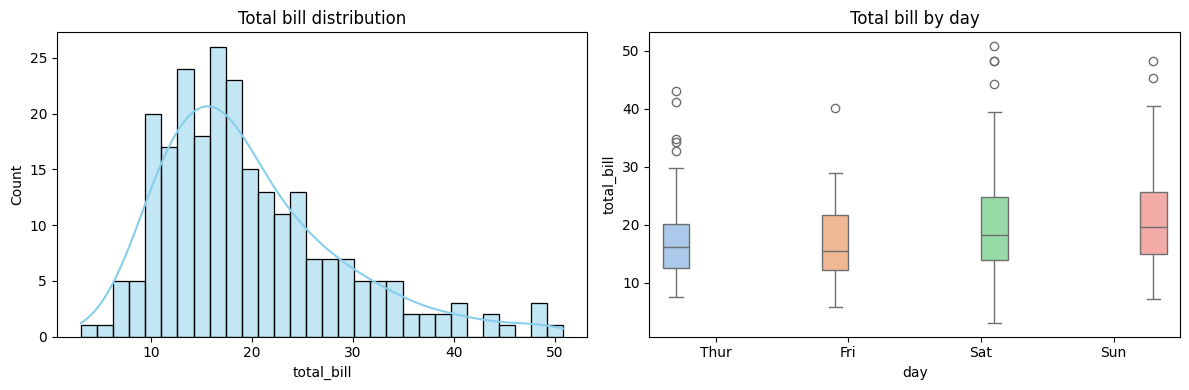

In [4]:
# ------------------------------------------------------------
# [목적] 왼쪽=결제액 분포(히스토그램+밀도곡선), 오른쪽=요일별 박스플롯
# ------------------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(12, 4))     # 1줄 2칸 (분포 그래프 + 비교 그래프)
sns.histplot(data=tips, x='total_bill', bins=30, kde=True, color='skyblue', ax=ax[0])  # 분포+밀도곡선
sns.boxplot(data=tips, x='day', y='total_bill', hue='day', palette='pastel', ax=ax[1]) # 요일별 요약
ax[0].set_title('Total bill distribution')        # 왼쪽 제목 (한글은 깨질 수 있어 영문)
ax[1].set_title('Total bill by day')              # 오른쪽 제목
plt.tight_layout()
plt.show()

In [5]:
# ============================================================
# [결과 해석]
#  · 왼쪽(histplot): 결제액이 10~20달러에 몰리고 오른쪽 꼬리가 김 (큰 결제는 소수)
#  · kde=True 밀도곡선이 분포 모양을 매끄럽게 보여줌
#  · 오른쪽(boxplot): 요일마다 결제액의 중앙값·퍼짐·이상치를 한눈에 비교 (주말이 대체로 높음)
#  · seaborn은 데이터프레임만 넘기면 분포·비교 그래프를 짧은 코드로 그려줌
# ============================================================